In [181]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.model_selection import train_test_split


from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

## Diabetes Prediction Project Overview
This project predicts diabetes risk using the Pima Indians Diabetes dataset. It demonstrates an end-to-end machine learning workflow that includes data cleaning, exploratory analysis, imbalance handling, and model comparison to support clinical risk prediction.

In [182]:
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Dataset Inspection
Loaded and inspected the dataset to understand feature distributions, summary statistics, and correlations. This step helps identify which clinical variables most strongly influence diabetes prediction.

In [183]:
df.head(15)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [184]:
df.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


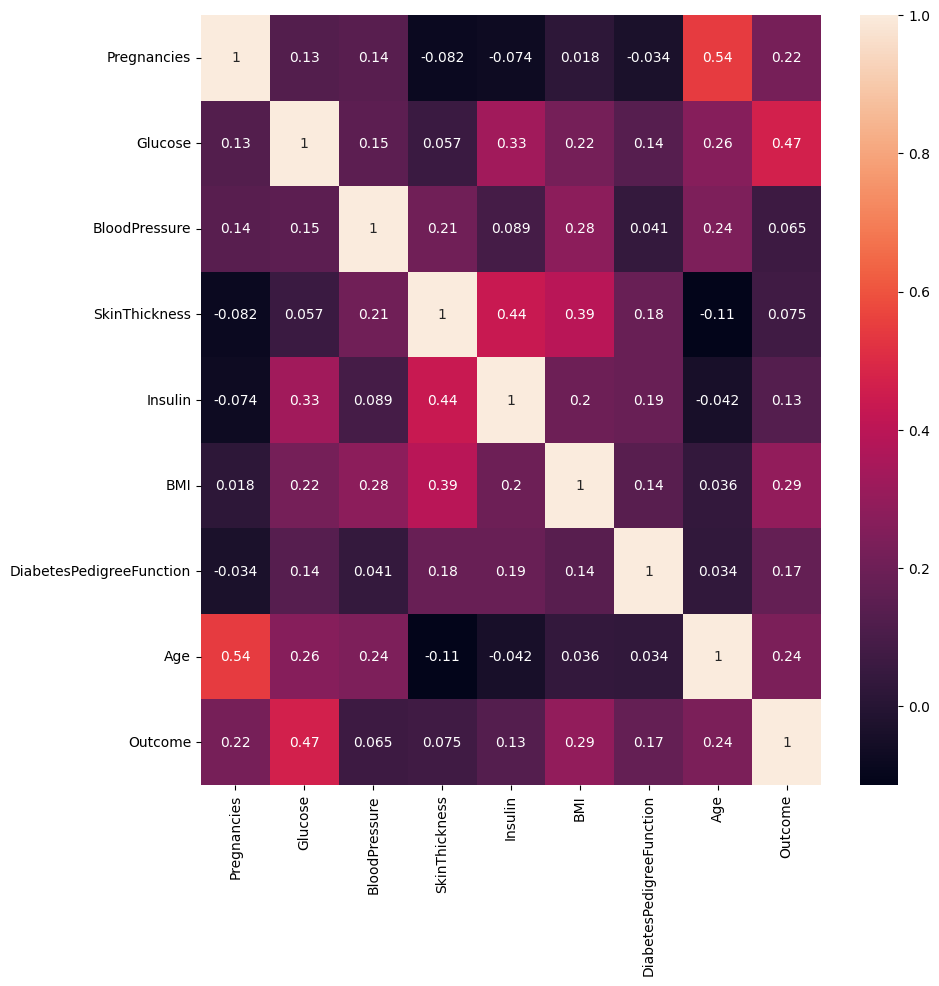

In [185]:
plt.figure(figsize = (10,10))
ax = sns.heatmap(df.corr(),annot = True)
plt.savefig('Dataset Heatmap.png')
plt.show()

## Exploratory Data Analysis (EDA)
Visualized feature distributions and correlations to identify patterns and prepare the dataset for modeling. These insights guide data cleaning and feature selection decisions.

In [186]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### Data Imputation Strategy
Replaced invalid zero values in clinical measurements with median or mean estimates. This improves dataset quality and prevents distorted model behavior from missing or implausible values.

<Axes: xlabel='Pregnancies', ylabel='Count'>

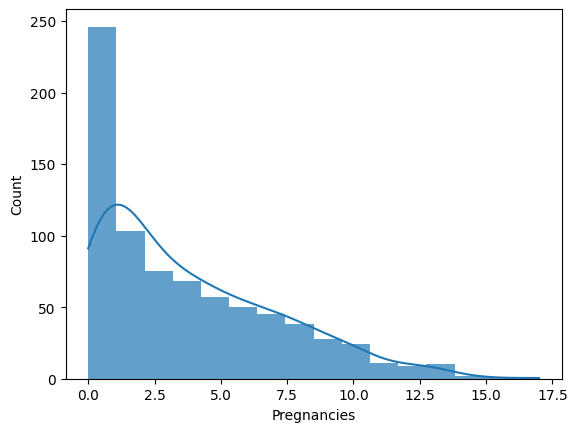

In [187]:
sns.histplot(df['Pregnancies'], kde = True, edgecolor = None, alpha = 0.7)

<Axes: xlabel='Glucose', ylabel='Count'>

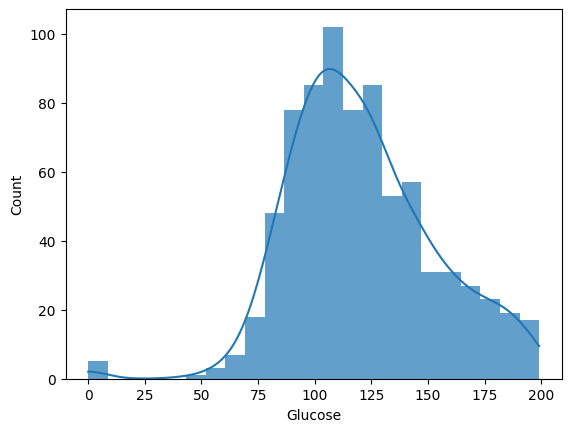

In [188]:
sns.histplot(df['Glucose'], kde = True, edgecolor = None, alpha = 0.7)

<Axes: xlabel='BloodPressure', ylabel='Count'>

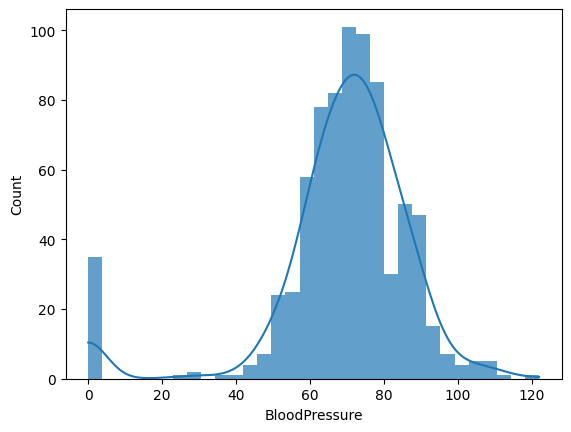

In [189]:
sns.histplot(df['BloodPressure'], kde = True, edgecolor = None, alpha = 0.7)

<Axes: xlabel='SkinThickness', ylabel='Count'>

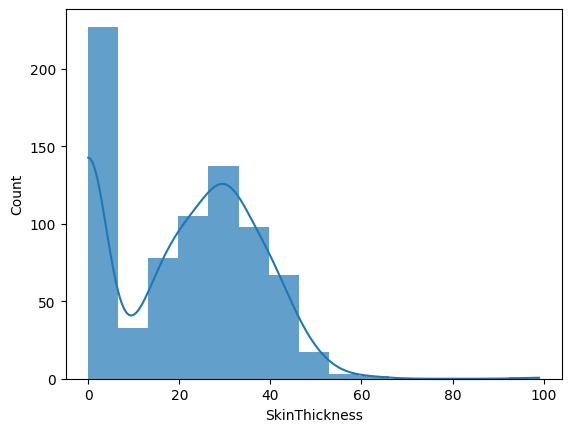

In [190]:
sns.histplot(df['SkinThickness'], kde = True, edgecolor = None, alpha = 0.7)

<Axes: xlabel='Insulin', ylabel='Count'>

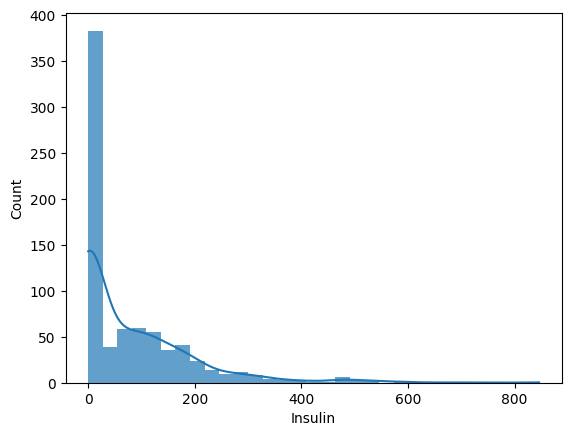

In [191]:
sns.histplot(df['Insulin'], kde = True, edgecolor = None, alpha = 0.7)

<Axes: xlabel='BMI', ylabel='Count'>

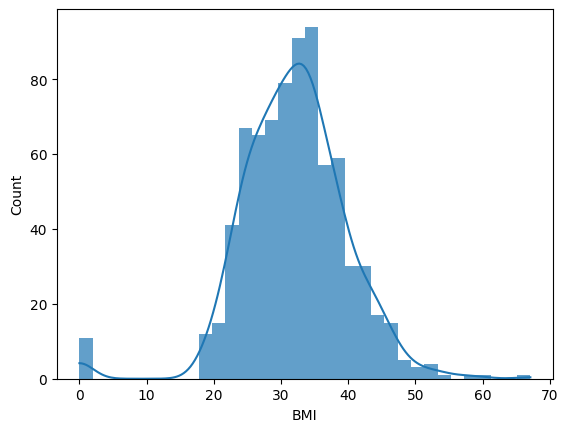

In [192]:
sns.histplot(df['BMI'], kde = True, edgecolor = None, alpha = 0.7)

<Axes: xlabel='DiabetesPedigreeFunction', ylabel='Count'>

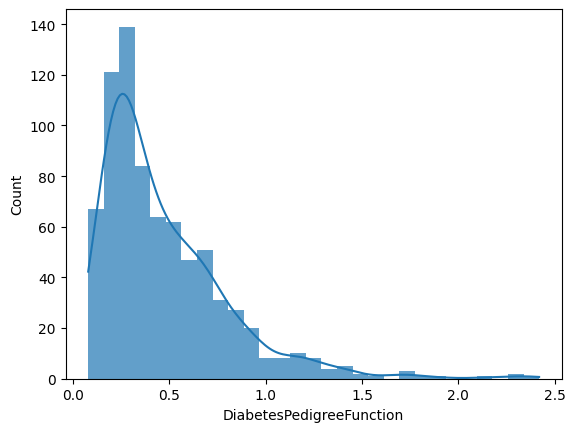

In [193]:
sns.histplot(df['DiabetesPedigreeFunction'], kde = True, edgecolor = None, alpha = 0.7)

<Axes: xlabel='Age', ylabel='Count'>

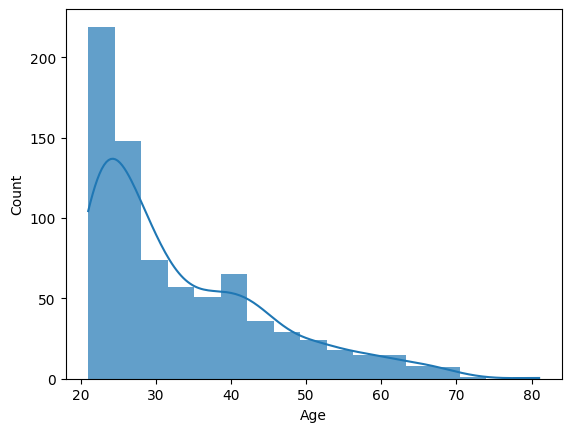

In [194]:
sns.histplot(df['Age'], kde = True, edgecolor = None, alpha = 0.7)

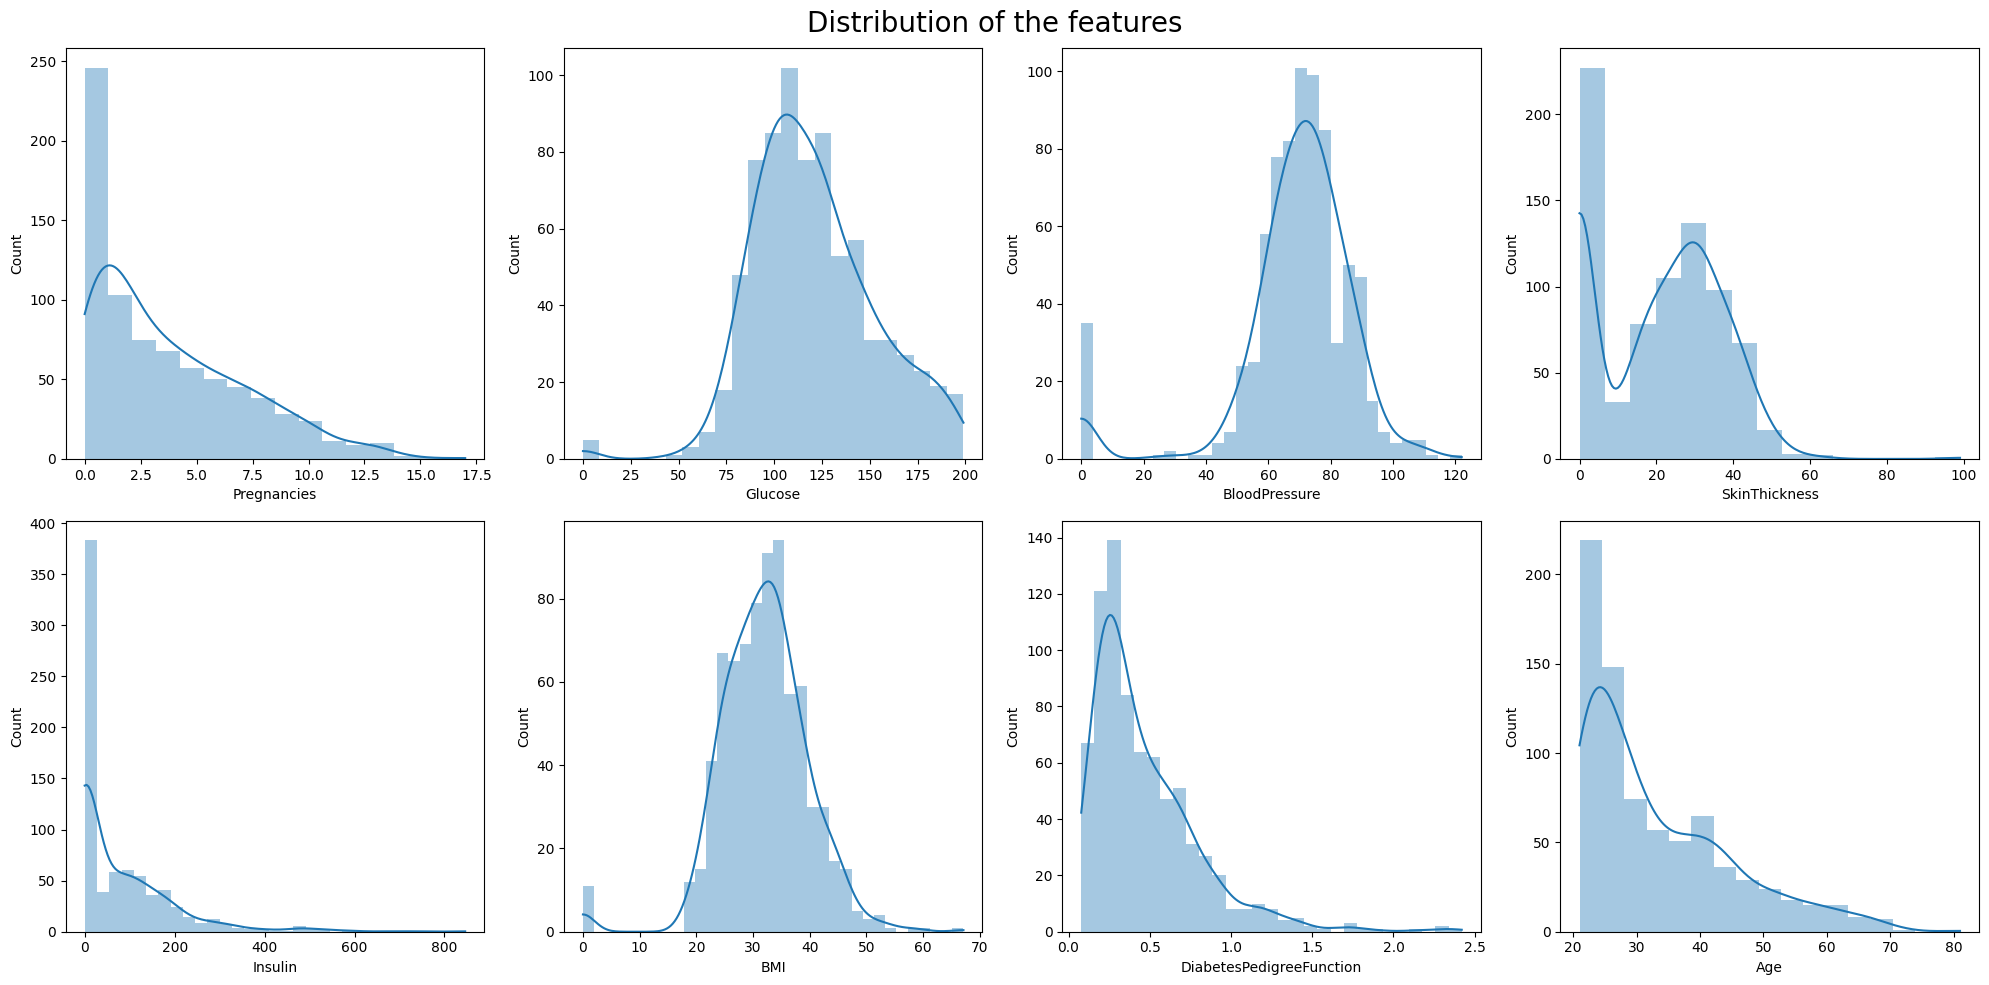

In [195]:
fig, ax = plt.subplots(2,4, figsize = (20,10))

for i in range(len(df.columns)-1):
    x = i // 4
    y = i % 4
    sns.histplot(df[df.columns[i]],ax = ax[x,y], kde = True, edgecolor = None, alpha = 0.4)

plt.suptitle('Distribution of the features', fontsize = 20)
plt.tight_layout()

In [196]:
df['Pregnancies']                 = df['Pregnancies'].replace(0, df['Pregnancies'].median())
df['Glucose']                     = df['Glucose'].replace(0, df['Glucose'].mean())
df['BloodPressure']               = df['BloodPressure'].replace(0, df['BloodPressure'].mean())
df['SkinThickness']               = df['SkinThickness'].replace(0, df['SkinThickness'].mean())
df['Insulin']                     = df['Insulin'].replace(0, df['Insulin'].median())
df['BMI']                         = df['BMI'].replace(0, df['BMI'].mean())
df['DiabetesPedigreeFunction']    = df['DiabetesPedigreeFunction'].replace(0, df['DiabetesPedigreeFunction'].median())
df['Age']                         = df['Age'].replace(0, df['Age'].median())


In [197]:
df.head(20)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.000000,35.000000,30.5,33.600000,0.627,50,1
1,1,85.0,66.000000,29.000000,30.5,26.600000,0.351,31,0
2,8,183.0,64.000000,20.536458,30.5,23.300000,0.672,32,1
3,1,89.0,66.000000,23.000000,94.0,28.100000,0.167,21,0
4,3,137.0,40.000000,35.000000,168.0,43.100000,2.288,33,1
5,5,116.0,74.000000,20.536458,30.5,25.600000,0.201,30,0
6,3,78.0,50.000000,32.000000,88.0,31.000000,0.248,26,1
7,10,115.0,69.105469,20.536458,30.5,35.300000,0.134,29,0
8,2,197.0,70.000000,45.000000,543.0,30.500000,0.158,53,1
9,8,125.0,96.000000,20.536458,30.5,31.992578,0.232,54,1


### Outlier Detection and Treatment
Used box plots and statistical thresholds to identify extreme values. This step reduces noise and ensures the model is trained on representative clinical examples.

In [198]:
x = df.drop(columns = 'Outcome', axis = 1)
y = df['Outcome']

<function matplotlib.pyplot.show(close=None, block=None)>

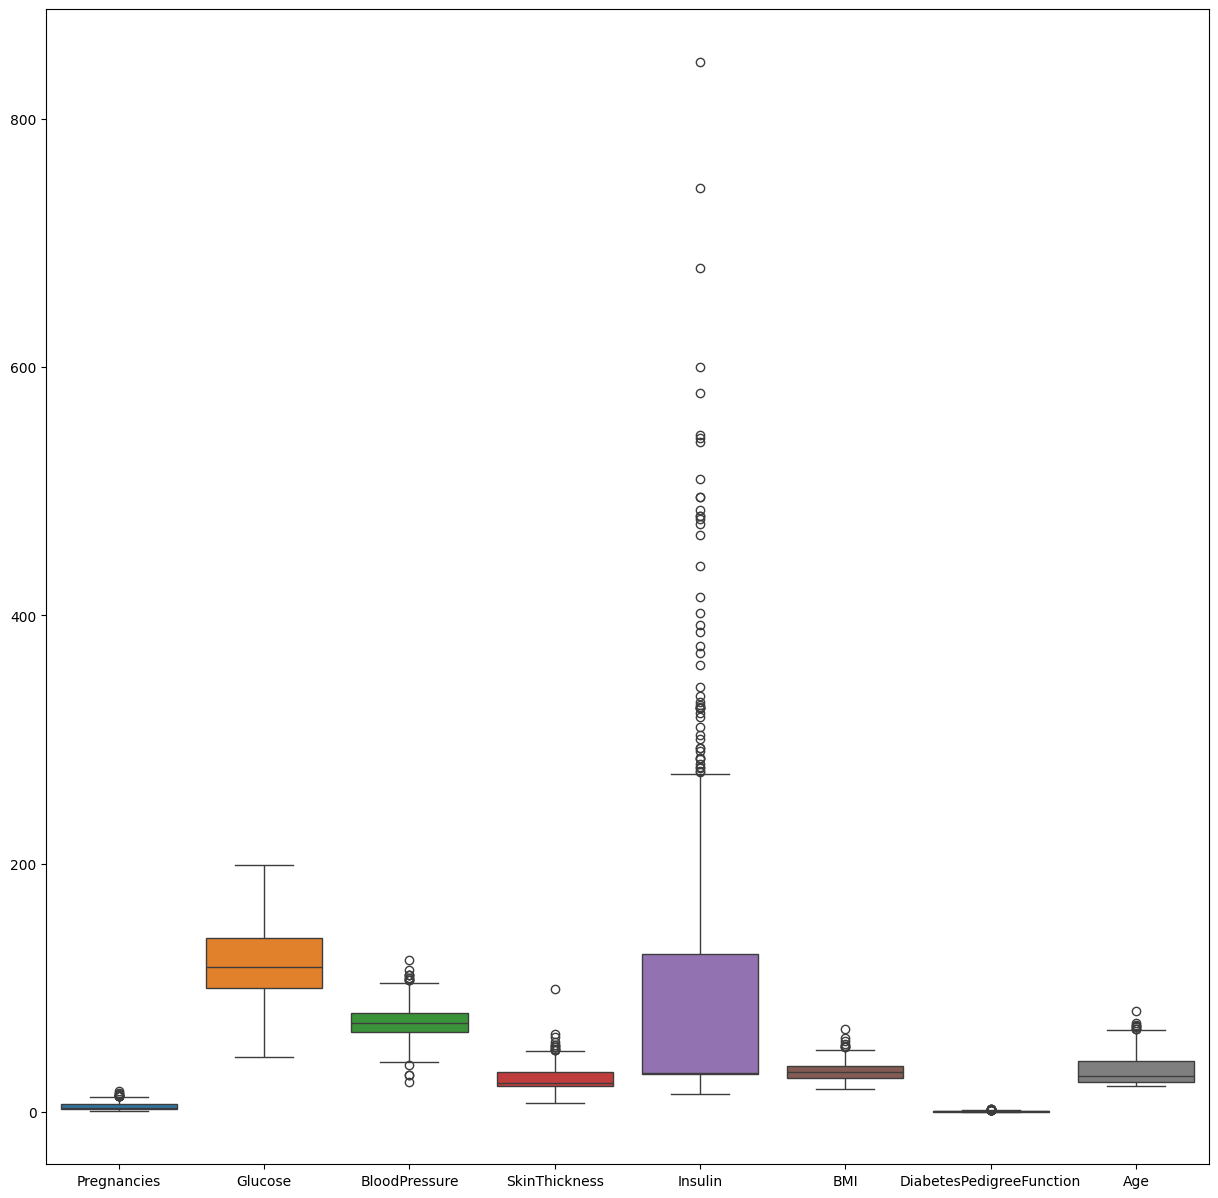

In [199]:
fig, ax = plt.subplots(figsize = (15,15))
sns.boxplot(data = x, ax = ax)
plt.savefig('Outlier Detection.png')
plt.show

In [200]:
for i in x.columns:
    q1    = x[i].quantile(.25)
    q3    = x[i].quantile(.75)
    iqr   = q3 - q1
    l_w   = q1 - 1.5 * iqr
    u_w   = q3 + 1.5 * iqr
    mask  = (x[i] > l_w) & (x[i] < u_w)

In [201]:
x_masked = x[mask]
y_masked = y[mask]

In [202]:
x_masked.shape

(759, 8)

In [203]:
y_masked.shape

(759,)

## Feature Scaling and Standardization
Standardized numeric features so all measurements contribute consistently to training. This improves classifier stability and helps algorithms converge faster.

In [204]:
x_masked_scaled = StandardScaler().fit_transform(x_masked)

In [205]:
x_masked_scaled.shape

(759, 8)

In [206]:
y_masked.shape

(759,)

<function matplotlib.pyplot.show(close=None, block=None)>

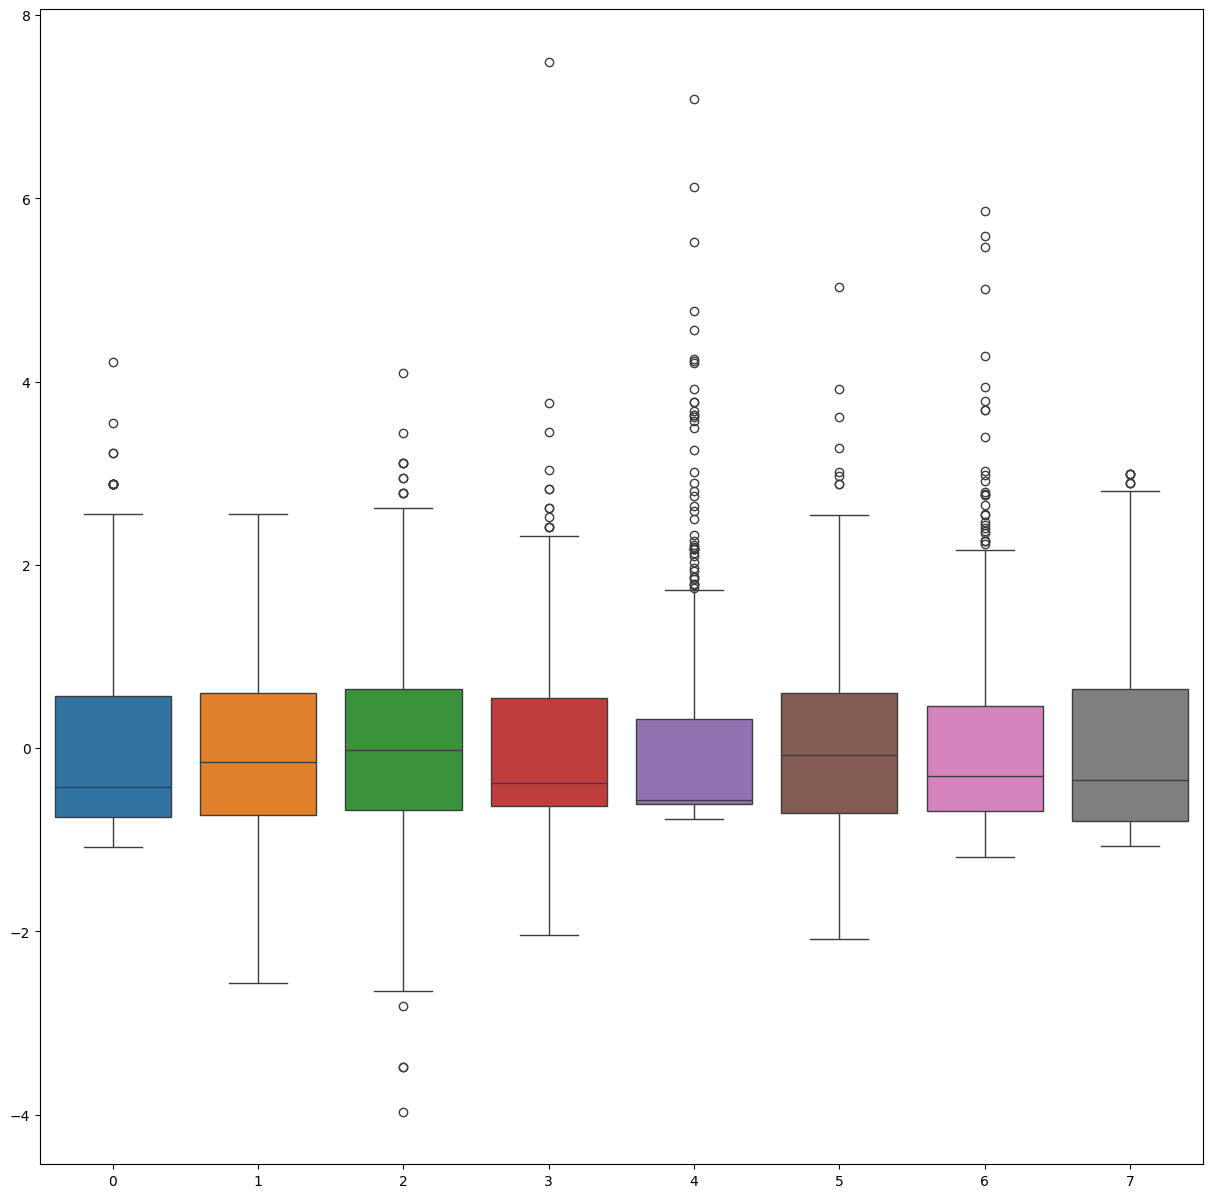

In [207]:
fig, ax = plt.subplots(figsize = (15,15))
sns.boxplot(data = x_masked_scaled, ax = ax)
plt.show

In [208]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

## Model Development and Evaluation
Built and compared classification models using cleaned, balanced data to identify the most reliable approach for diabetes risk prediction.

### Train/Test Split
Split the processed data into training and testing subsets to evaluate model generalization on unseen patient data.

In [209]:
x_t, x_test, y_t, y_test = train_test_split(x_masked_scaled, y_masked, test_size = 0.33, random_state = 42)

In [210]:
x_t.shape

(508, 8)

In [211]:
y_t.value_counts()

Outcome
0    328
1    180
Name: count, dtype: int64

### Handling Class Imbalance
Applied SMOTE oversampling to balance the training labels and improve detection of minority diabetic cases while limiting bias toward the majority class.

In [212]:
smote = SMOTE(random_state = 42)
x_new_tr, y_new_tr = smote.fit_resample(x_t, y_t)

In [213]:
y_new_tr.value_counts()

Outcome
1    328
0    328
Name: count, dtype: int64

In [214]:
def hyperparameter_tuning(model, param_grid, model_name):
    cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

    grid_model = GridSearchCV(estimator = model, param_grid = param_grid, cv = cv, n_jobs = -1, verbose = 1, scoring = 'recall')

    grid_model.fit(x_new_tr, y_new_tr)

    best_params = grid_model.best_params_
    best_model = grid_model.best_estimator_

    report = classification_report(y_test, best_model.predict(x_test), target_names = target_name, output_dict=True)
    precision_diabetic = report['Diabetic']['precision']
    precision_non_diabetic = report['Non-Diabetic']['precision']
    recall_diabetic = report['Diabetic']['recall']
    recall_non_diabetic = report['Non-Diabetic']['recall']
    accuracy_score = report['accuracy']

    matrix = {
        'Precision_diabetic': precision_diabetic,
        'Precision_non_diabetic': precision_non_diabetic,
        'Recall_diabetic': recall_diabetic,
        'Recall_non_diabetic': recall_non_diabetic,
        'Accuracy': accuracy_score
    }
    df_matrix = pd.DataFrame(matrix, index = [model_name])
    df_matrix
    
    
    return best_model, best_params,  df_matrix

### Logistic Regression Training
Trained a logistic regression classifier as a baseline diabetes prediction model using the balanced training dataset.

In [215]:
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'max_iter': [100, 200, 500]
}

lr = LogisticRegression()

best_model_lr, best_params_lr, lr_eval = hyperparameter_tuning(lr, param_grid_lr, 'Logistic Regression')

lr_eval

Fitting 5 folds for each of 60 candidates, totalling 300 fits


,Precision_diabetic,Precision_non_diabetic,Recall_diabetic,Recall_non_diabetic,Accuracy
Logistic Regression,0.574257,0.813333,0.674419,0.739394,0.717131


## K-Nearest Neighbors Model
Trained a KNN classifier to compare performance against logistic regression and test model robustness on the balanced dataset.

In [216]:
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

knn = KNeighborsClassifier()

best_model_knn, best_params_knn, knn_eval = hyperparameter_tuning(knn, param_grid_knn, 'KNN')

knn_eval

Fitting 5 folds for each of 42 candidates, totalling 210 fits


,Precision_diabetic,Precision_non_diabetic,Recall_diabetic,Recall_non_diabetic,Accuracy
KNN,0.516393,0.821705,0.732558,0.642424,0.673307


## Decision Tree Model
Built a decision tree classifier to compare a non-linear, interpretable model for diabetes risk prediction and visualize decision rules.

In [217]:
dt = DecisionTreeClassifier()

param_grid_dt = {
    'criterion':['gini', 'entropy'],
    'max_depth':range(5,16),
    'min_samples_split':range(2,11)
}

best_model_dt, best_params_dt, dt_eval = hyperparameter_tuning(dt, param_grid_dt, 'Decision Tree')
dt_eval

Fitting 5 folds for each of 198 candidates, totalling 990 fits


,Precision_diabetic,Precision_non_diabetic,Recall_diabetic,Recall_non_diabetic,Accuracy
Decision Tree,0.595745,0.808917,0.651163,0.769697,0.729084


## Random Forest

In [218]:
rf = RandomForestClassifier()

param_grid_rf = {
    'n_estimators' : [2,5,10,20,100,150],
    'criterion' : ['grid', 'entropy'],
    'max_depth' : range(10),
    'min_samples_leaf' : range(10)
}

best_model, best_params, rf_eval = hyperparameter_tuning(rf, param_grid_rf, 'RandomForest')
rf_eval

Fitting 5 folds for each of 1200 candidates, totalling 6000 fits


,Precision_diabetic,Precision_non_diabetic,Recall_diabetic,Recall_non_diabetic,Accuracy
RandomForest,0.588785,0.840278,0.732558,0.733333,0.733068


In [219]:
model_evaluation = pd.concat([lr_eval, knn_eval, dt_eval, rf_eval])
model_evaluation.sort_values(by = 'Recall_diabetic', ascending = False)

,Precision_diabetic,Precision_non_diabetic,Recall_diabetic,Recall_non_diabetic,Accuracy
KNN,0.516393,0.821705,0.732558,0.642424,0.673307
RandomForest,0.588785,0.840278,0.732558,0.733333,0.733068
Logistic Regression,0.574257,0.813333,0.674419,0.739394,0.717131
Decision Tree,0.595745,0.808917,0.651163,0.769697,0.729084


## Project Summary
- Completed a full diabetes prediction pipeline from data ingestion to model evaluation.
- Improved data quality through imputation, outlier detection, and feature scaling.
- Addressed class imbalance with SMOTE to ensure fair detection of diabetic cases.
- Compared logistic regression, KNN, and decision tree classifiers to determine the most effective model.
- Demonstrated practical machine learning skills for healthcare risk prediction and model explainability.